# mask-to-mri — Synthetic MRI Generation with pix2pix

This notebook runs the full pipeline: data exploration → model training → evaluation.

**Experiment A:** Train pix2pix to generate realistic MRI from masks.  
**Experiment B:** Measure segmentation improvement with synthetic data.

## 0 — Colab Setup

In [1]:
import os, shutil

os.chdir('/content')
if not os.path.exists('Mask-to-MRI'):
    !git clone https://github.com/AmineAitLaamim/Mask-to-MRI

%cd Mask-to-MRI

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Dataset symlink (fast)
os.makedirs('data/raw', exist_ok=True)
if not os.path.exists('data/raw/lgg-mri-segmentation'):
    os.symlink(
        '/content/drive/MyDrive/mask-to-mri/dataset/lgg-mri-segmentation',
        'data/raw/lgg-mri-segmentation'
    )

# Outputs symlink to Drive (persists across disconnects)
os.makedirs('outputs', exist_ok=True)
for d in ['checkpoints', 'samples', 'metrics']:
    local = f'outputs/{d}'
    remote = f'/content/drive/MyDrive/mask-to-mri/outputs/{d}'
    os.makedirs(remote, exist_ok=True)
    if os.path.islink(local) or os.path.exists(local):
        os.remove(local) if os.path.islink(local) else None
    os.symlink(remote, local, target_is_directory=True)

!pip install -q torch torchvision albumentations opencv-python tifffile scikit-image pytorch-fid segmentation-models-pytorch pyyaml matplotlib numpy Pillow tqdm

print(f"Dir: {os.getcwd()}")
print("Files:", os.listdir('.'))

Cloning into 'Mask-to-MRI'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 48 (delta 15), reused 43 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 781.91 KiB | 12.61 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/Mask-to-MRI
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00
Dir: /content/Mask-to-MRI
Files: ['data', 'src', 'mask_to_mri.ipynb', 'pyproject.toml', '.git', 'README.md', '.python-version', 'uv.lock', 'requirements.txt', 'notebooks', 'outputs', '.gitignore', 'prepare_splits.py', 'config.yaml', 'main.py']


## 1 — Config & Imports

In [2]:
import sys
sys.path.insert(0, '.')

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt

with open('config.yaml') as f:
    config = yaml.safe_load(f)

print("Configuration:")
print(yaml.dump(config, default_flow_style=False))

from src.utils import fix_seed
fix_seed(config['data']['seed'])
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Device: {device}")

Configuration:
data:
  image_size: 256
  processed_dir: data/processed
  raw_dir: data/raw/lgg-mri-segmentation
  seed: 42
  synthetic_dir: data/synthetic
model:
  input_channels: 1
  norm: instance
  num_filters: 64
  output_channels: 3
paths:
  checkpoints: outputs/checkpoints
  metrics: outputs/metrics
  samples: outputs/samples
training:
  batch_size: 1
  beta1: 0.5
  beta2: 0.999
  epochs: 200
  lambda_l1: 100
  lr: 0.0002
  save_every: 5

  → Random seed fixed: 42
Device: cuda


## 2 — Data Exploration

In [3]:
from src.dataset import get_patient_file_list
import tifffile
import os

raw_dir = config['data']['raw_dir']
patient_data = get_patient_file_list(raw_dir)

print(f"Total patients: {len(patient_data)}")
print(f"Sample patients: {list(patient_data.keys())[:5]}")

total_slices = sum(len(v) for v in patient_data.values())
slices_per_patient = [len(v) for v in patient_data.values()]
print(f"Total slices: {total_slices}")
print(f"Per patient: min={min(slices_per_patient)}, max={max(slices_per_patient)}, avg={np.mean(slices_per_patient):.1f}")

Total patients: 110
Sample patients: ['TCGA_CS_4941_19960909', 'TCGA_CS_4942_19970222', 'TCGA_CS_4943_20000902', 'TCGA_CS_4944_20010208', 'TCGA_CS_5393_19990606']
Total slices: 3929
Per patient: min=20, max=88, avg=35.7


Patient: TCGA_CS_4941_19960909 | Tumor slice: 1
Image: (256, 256, 3) uint8
  R/T1: min=0, max=207, mean=42.2
  G/FLAIR: min=0, max=222, mean=42.3
  B/T2: min=0, max=248, mean=42.5
Mask values: [  0 255]


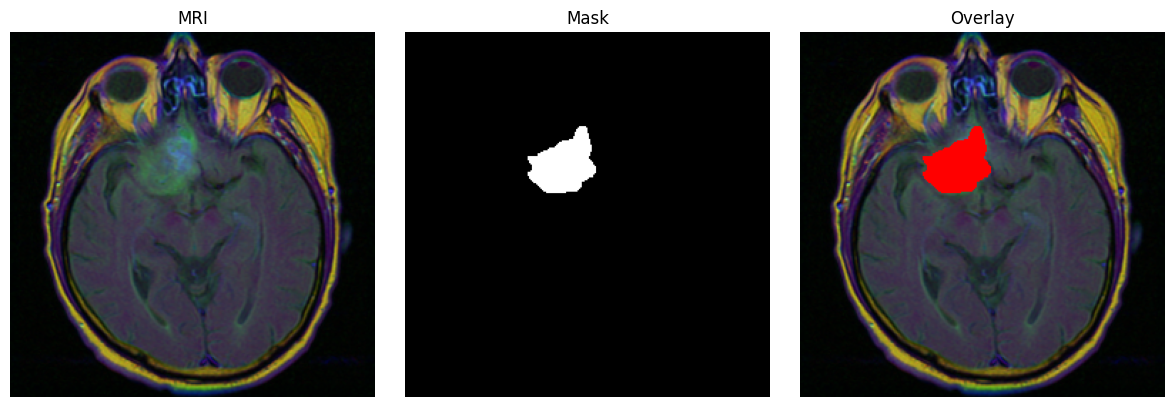

In [4]:
# Find a slice with tumor pixels
first_patient = list(patient_data.keys())[0]
p_dir = os.path.join(raw_dir, first_patient)
mask_files = sorted([f for f in os.listdir(p_dir) if f.endswith('_mask.tif')])

tumor_idx = None
for i, mf in enumerate(mask_files):
    m = tifffile.imread(os.path.join(p_dir, mf))
    if m.max() > 0:
        tumor_idx = i
        mask_path = os.path.join(p_dir, mf)
        img_path = os.path.join(p_dir, mf.replace('_mask.tif', '.tif'))
        break

if tumor_idx is not None:
    image = tifffile.imread(img_path)
    mask = tifffile.imread(mask_path)

    print(f"Patient: {first_patient} | Tumor slice: {tumor_idx}")
    print(f"Image: {image.shape} {image.dtype}")
    for i, ch in enumerate(['R/T1', 'G/FLAIR', 'B/T2']):
        print(f"  {ch}: min={image[:,:,i].min()}, max={image[:,:,i].max()}, mean={image[:,:,i].mean():.1f}")
    print(f"Mask values: {np.unique(mask)}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image); axes[0].set_title('MRI'); axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Mask'); axes[1].axis('off')
    overlay = image.copy()
    overlay[mask > 0] = [255, 0, 0]
    axes[2].imshow(overlay); axes[2].set_title('Overlay'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No tumor found in first patient.")

## 3 — DataLoaders (pre-filtered, instant load)

In [5]:
import json
from src.dataset import LGGDataset, get_patient_file_list, patient_level_split

raw_dir = config['data']['raw_dir']
splits_path = '/content/drive/MyDrive/mask-to-mri/dataset/splits'
dataset_root = 'data/raw/lgg-mri-segmentation'

# Load pre-filtered splits if available
if all(os.path.exists(f'{splits_path}/{s}_split.json') for s in ['train', 'val', 'test']):
    print("Loading pre-filtered splits from Drive...")
    def load_split(name):
        pairs = json.load(open(f'{splits_path}/{name}_split.json'))
        return [(f"{dataset_root}/{p[0]}", f"{dataset_root}/{p[1]}") for p in pairs]

    train_pairs = load_split('train')
    val_pairs = load_split('val')
    test_pairs = load_split('test')
else:
    print("No pre-filtered splits found — building from scratch (slow)...")
    patient_data = get_patient_file_list(raw_dir)
    splits = patient_level_split(patient_data, seed=config['data']['seed'])
    train_pairs, val_pairs, test_pairs = splits['train'], splits['val'], splits['test']

print(f"Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")

# Build DataLoaders
def make_loader(pairs, shuffle, aug):
    ds = LGGDataset(pairs, image_size=256, augment=aug, seed=42, filter_empty_masks=False)
    return torch.utils.data.DataLoader(ds, batch_size=1, shuffle=shuffle, num_workers=2)

loaders = {
    'train': make_loader(train_pairs, shuffle=True, aug=True),
    'val': make_loader(val_pairs, shuffle=False, aug=False),
    'test': make_loader(test_pairs, shuffle=False, aug=False),
}
print("DataLoaders ready.")

Loading pre-filtered splits from Drive...
Train: 1065, Val: 151, Test: 157
DataLoaders ready.


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Mask: (1, 1, 256, 256)  Image: (1, 3, 256, 256)
Mask range: [-1.00, 1.00]
Image range: [-1.00, 0.32]


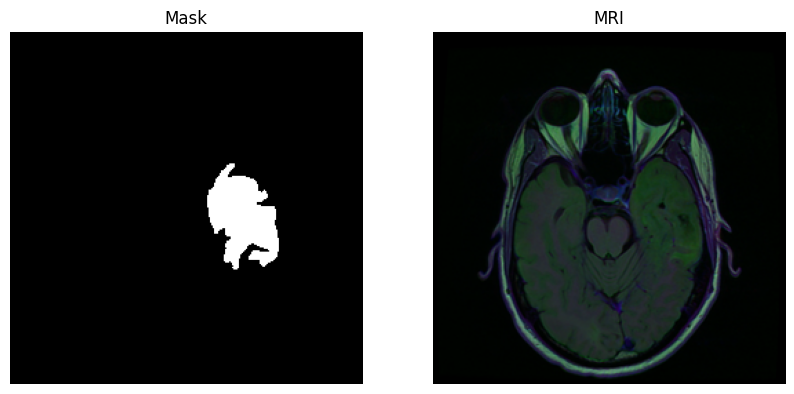

In [6]:
mask, img = next(iter(loaders['train']))
print(f"Mask: {tuple(mask.shape)}  Image: {tuple(img.shape)}")
print(f"Mask range: [{mask.min():.2f}, {mask.max():.2f}]")
print(f"Image range: [{img.min():.2f}, {img.max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
mask_vis = ((mask[0, 0].numpy() + 1.0) * 127.5).astype(np.uint8)
img_vis = ((img[0].numpy().transpose(1, 2, 0) + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
axes[0].imshow(mask_vis, cmap='gray'); axes[0].set_title('Mask'); axes[0].axis('off')
axes[1].imshow(img_vis); axes[1].set_title('MRI'); axes[1].axis('off')
plt.show()

## 4 — Models

In [7]:
import torch
from src.generator import create_generator
from src.discriminator import create_discriminator
from src.utils import print_model_summary

torch.cuda.empty_cache()

m = config['model']
G = create_generator(
    in_channels=m['input_channels'],
    out_channels=m['output_channels'],
    num_filters=m['num_filters'],
    norm=m['norm'],
).to(device)

D = create_discriminator(
    in_channels=m['input_channels'] + m['output_channels'],
    num_filters=m['num_filters'],
).to(device)

assert next(G.parameters()).device.type == device.type, "G not on GPU!"
assert next(D.parameters()).device.type == device.type, "D not on GPU!"

print_model_summary('Generator (U-Net)', G)
print_model_summary('Discriminator (PatchGAN)', D)

  Generator (U-Net): 10,750,659 parameters (10.75M)
  Discriminator (PatchGAN): 2,764,865 parameters (2.76M)


In [8]:
with torch.no_grad():
    fake = G(mask.to(device))
    d_real = D(mask.to(device), img.to(device))
    d_fake = D(mask.to(device), fake)

assert fake.shape == img.shape, f"Shape mismatch: {fake.shape} != {img.shape}"
assert fake.min() >= -1.01 and fake.max() <= 1.01, f"fake range: [{fake.min():.3f}, {fake.max():.3f}]"

print(f"✓ G output: {tuple(fake.shape)}  range: [{fake.min():.3f}, {fake.max():.3f}]")
print(f"✓ D real: {tuple(d_real.shape)}")
print(f"✓ D fake: {tuple(d_fake.shape)}")
print("✓ All checks passed — ready to train")

✓ G output: (1, 3, 256, 256)  range: [-0.998, 0.999]
✓ D real: (1, 1, 30, 30)
✓ D fake: (1, 1, 30, 30)
✓ All checks passed — ready to train


## 5 — Training

In [ ]:
import time, glob, os
from src.train import train

def find_latest_checkpoint(checkpoint_dir):
    if not os.path.exists(checkpoint_dir):
        return None
    ckpts = glob.glob(os.path.join(checkpoint_dir, "checkpoint_epoch_*.pt"))
    if not ckpts:
        return None
    return max(ckpts, key=lambda p: int(p.rsplit("_", 1)[1].split(".")[0]))

gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {torch.cuda.get_device_name(0)} ({gpu_mem:.1f} GB total)")
print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB\n")

ckpt = find_latest_checkpoint(config['paths']['checkpoints'])
if ckpt:
    print(f"⚡ Found checkpoint: {ckpt}")
    print("   → Training will auto-resume from that epoch\n")
else:
    print("No checkpoint found — starting from epoch 1\n")

start = time.time()
try:
    history = train(
        train_loader=loaders['train'],
        val_loader=loaders['val'],
        generator=G,
        discriminator=D,
        config=config,
        device=device,
        checkpoint_dir=config['paths']['checkpoints'],
        samples_dir=config['paths']['samples'],
    )
    print(f"\n✓ Training complete in {time.time()-start:.0f}s")
except KeyboardInterrupt:
    elapsed = time.time() - start
    print(f"\n⏹ Training interrupted after {elapsed:.0f}s")
    print("Checkpoint already saved — resume by re-running this cell")

GPU: Tesla T4 (15.6 GB total)
Allocated: 0.06 GB

No checkpoint found — starting from epoch 1


Training pix2pix: epoch 1–200 of 200
  LR=0.0002, beta1=0.5, lambda_L1=100
  Schedule: 100 epochs constant + 100 epochs linear decay
  Checkpoint every 5 epochs



Epoch 1/200:  33%|███▎      | 355/1065 [01:46<03:50,  3.08it/s, D=0.0866, G=13.0313]

In [ ]:
from src.utils import plot_loss_curves
plot_loss_curves(history, save_path='outputs/samples/loss_curves.png')

## 6 — Generate Synthetic MRI

In [ ]:
import os, glob
from PIL import Image
from src.train import load_checkpoint

ckpts = sorted(glob.glob('outputs/checkpoints/checkpoint_epoch_*.pt'))
if ckpts:
    epoch = load_checkpoint(ckpts[-1], G, D)
    print(f"Loaded epoch {epoch}")

G.eval()
syn_dir = config['data']['synthetic_dir']
os.makedirs(syn_dir, exist_ok=True)

count = 0
with torch.no_grad():
    for mask, real in loaders['test']:
        fake = G(mask.to(device))
        fake_np = ((fake[0].cpu().permute(1, 2, 0).numpy() + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
        real_np = ((real[0].cpu().permute(1, 2, 0).numpy() + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
        Image.fromarray(fake_np).save(os.path.join(syn_dir, f'fake_{count:04d}.png'))
        Image.fromarray(real_np).save(os.path.join(syn_dir, f'real_{count:04d}.png'))
        count += 1
print(f"Saved {count} pairs → {syn_dir}")

## 7 — Evaluation (Exp A)

In [ ]:
from src.evaluate import compute_ssim_batch, compute_psnr_batch, save_eval_results

all_ssim, all_psnr = [], []
G.eval()
with torch.no_grad():
    for mask, real in loaders['test']:
        fake = G(mask.to(device))
        all_ssim.append(compute_ssim_batch(fake, real))
        all_psnr.append(compute_psnr_batch(fake, real))

mean_ssim = np.mean(all_ssim)
mean_psnr = np.mean(all_psnr)
print(f"SSIM: {mean_ssim:.4f}")
print(f"PSNR: {mean_psnr:.2f} dB")

In [ ]:
metrics = {
    'ssim': round(mean_ssim, 4),
    'psnr': round(mean_psnr, 2),
}
save_eval_results(metrics, metrics_dir=config['paths']['metrics'], prefix='eval_exp_a')

## 8 — Experiment B (Segmentation)

In [ ]:
import segmentation_models_pytorch as smp
from tqdm import tqdm
from src.losses import DiceBCELoss
from src.evaluate import compute_dice_score

def train_segmentation(train_loader, val_loader, epochs=50):
    model = smp.Unet(
        encoder_name="resnet18",
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation="sigmoid",
    ).to(device)
    criterion = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for ep in range(1, epochs + 1):
        model.train()
        loss_sum = 0
        for img, mask in tqdm(train_loader, desc=f"Seg {ep}/{epochs}", leave=False):
            img, mask = img.to(device), mask.to(device)
            mask_bin = (mask + 1.0) / 2.0
            pred = model(img)
            loss = criterion(pred, mask_bin)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
        if ep % 10 == 0:
            print(f"  Ep {ep}: loss={loss_sum/len(train_loader):.4f}")

    model.eval()
    dices = []
    with torch.no_grad():
        for img, mask in val_loader:
            pred = model(img.to(device))
            pred_b = (pred.cpu().numpy() > 0.5).astype(np.float32)
            mask_b = ((mask + 1.0) / 2.0).numpy()
            dices.append(compute_dice_score(pred_b, mask_b))
    return np.mean(dices)

# dice_real = train_segmentation(loaders['train'], loaders['test'], epochs=50)
# print(f"Dice (real only): {dice_real:.4f}")

## 9 — Final Results

In [ ]:
print("=" * 50)
print("mask-to-mri — Results")
print("=" * 50)
print(f"SSIM: {mean_ssim:.4f}")
print(f"PSNR: {mean_psnr:.2f} dB")
print(f"Synthetic samples: {count}")
print("=" * 50)